In [ ]:
 # https://keras.io/examples/rl/ddpg_pendulum/

In [ ]:
import gym
import tensorflow as tf
import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.linalg import matrix_power
from scipy.linalg import block_diag

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle

In [ ]:
import gym
from gym import spaces
from gym.utils import seeding
import numpy as np
from os import path

class custom_PendulumEnv(gym.Env):
    metadata = {
        'render.modes' : ['human', 'rgb_array'],
        'video.frames_per_second' : 30
    }

    def __init__(self):
        self.max_speed=8
        self.max_torque=2.
        self.dt=.05
        self.NumIntegrationsSteps = 1#5 #3
        self.viewer = None
        self.max_step = 200
        self.current_step = 0

        high = np.array([1., 1., self.max_speed])
        self.action_space = spaces.Box(low=-self.max_torque, high=self.max_torque, shape=(1,))
        self.observation_space = spaces.Box(low=-high, high=high)

        self.seed()

        ### Customization changes ############################
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60
        dt_prime = self.dt/self.NumIntegrationsSteps
        self.MPC.dt = dt_prime
        self.MPC.plant.tau1 = dt_prime
        self.MPC.ref_model.tau1 = dt_prime
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0
        ####


    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def step(self,action):
        th, thdot = self.state # th := theta
        newth, newthdot = self.state # th := theta

        g = 10.
        m = 1.
        l = 1.
        dt = self.dt/self.NumIntegrationsSteps

        wanted_torque = np.clip(action, -self.max_torque, self.max_torque)[0] #numpy.clip() function is used to Clip (limit) the values in an array
        #wanted_torque_ret = self.wanted_torque
        self.MPC.y_spf = wanted_torque
        beta_AF = 0.135
        wanted_torque = (beta_AF)*self.wanted_torque+(1-beta_AF)*wanted_torque
        self.wanted_torque = wanted_torque
        self.MPC.y[0] = wanted_torque #self.MPC.y_spf #wanted_torque #wanted_torque_ret
        wanted_torque_ret = self.wanted_torque
        for n in np.arange(start=0, stop=self.NumIntegrationsSteps, step=1):
          self.MPC.plant.thetadot = newthdot
          actual_torque = self.MPC.step()
          newthdot = newthdot + (-3*g/(2*l) * np.sin(newth + np.pi) + 3./(m*l**2)*actual_torque) * dt
          newth = newth + (newthdot+self.MPC.plant.thetadot)*dt/2
          newthdot = np.clip(newthdot, -self.max_speed, self.max_speed) #pylint: disable=E1111 #numpy.clip() function is used to Clip (limit) the values in an array

        self.last_u = actual_torque
        costs = angle_normalize(th)**2 + .1*thdot**2 + .001*(actual_torque**2)
        self.state = np.array([newth, newthdot])

        self.current_step += 1
        done = bool(self.current_step % self.max_step == 0)

        return self._get_obs(), -costs, done, {} , wanted_torque_ret , actual_torque


    def reset(self):
        high = np.array([np.pi, 1])
        self.state = self.np_random.uniform(low=-high, high=high)
        self.last_u = None

        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0

        return self._get_obs()

    def _get_obs(self):
        theta, thetadot = self.state
        return np.array([np.cos(theta), np.sin(theta), thetadot])

    def render(self, mode='human'):

        if self.viewer is None:
            from gym.envs.classic_control import rendering
            self.viewer = rendering.Viewer(500,500)
            self.viewer.set_bounds(-2.2,2.2,-2.2,2.2)
            rod = rendering.make_capsule(1, .2)
            rod.set_color(.8, .3, .3)
            self.pole_transform = rendering.Transform()
            rod.add_attr(self.pole_transform)
            self.viewer.add_geom(rod)
            axle = rendering.make_circle(.05)
            axle.set_color(0,0,0)
            self.viewer.add_geom(axle)
            fname = path.join(path.dirname(__file__), "assets/clockwise.png")
            self.img = rendering.Image(fname, 1., 1.)
            self.imgtrans = rendering.Transform()
            self.img.add_attr(self.imgtrans)

        self.viewer.add_onetime(self.img)
        self.pole_transform.set_rotation(self.state[0] + np.pi/2)
        if self.last_u:
            self.imgtrans.scale = (-self.last_u/2, np.abs(self.last_u)/2)

        return self.viewer.render(return_rgb_array = mode=='rgb_array')

    def close(self):
        if self.viewer: self.viewer.close()

def angle_normalize(x):
    return (((x+np.pi) % (2*np.pi)) - np.pi)

In [ ]:
class ElectricalDCMotorEnv():

  def __init__(self):
    self.Resistor_R = 1.0
    self.inductor_L = 0.1
    self.torque_const_Kt = 1.0
    self.bemf_const_Ke = 1.0
    self.tau1 = 0.05
    self.ZOH_mode = True
        #
    self.current = 0.0
    self.voltage_input = None
    self.thetadot = 0.0
    self.F = 0.0

  def step(self, u):
    voltage_BEMF = self.thetadot*self.bemf_const_Ke
    self.voltage_input = np.clip(u, -10, 10)

    f1 = self.torque_const_Kt*self.current
    if self.ZOH_mode:
      a = np.exp(-self.tau1*self.Resistor_R/self.inductor_L)
      self.current = a*self.current + (1-a)/self.Resistor_R*(u-voltage_BEMF)
    else:
      self.current += self.tau1*(self.voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
    f2 = self.torque_const_Kt*self.current
    self.F=f2 #f1 #f2 #(f1+f2)/2
    return self.F # return actual applied torque

  def reset(self):
    self.current = 0.0
    self.F = 0.0


In [ ]:
class ReferenceModel():

  def __init__(self):
    self.tau1 = 0.05
    self.A_rm = np.array([[0]])
    self.B_rm = np.array([[0]])
    self.y_rm = np.array([[0]])

  def step(self, u):
    # TODO: complete
    #for _ in range(0,1):
    y_m_prev = self.y_rm+0
    self.y_rm = self.A_rm@self.y_rm + self.B_rm*u
    return self.y_rm #y_m_prev #self.y_rm

  def reset(self):
    self.y_rm = np.array([[0]])




In [ ]:
class ModelPredictCtrl:

  def __init__(self,dt=0.01, N=60,
               a_sp = 1, b_sp = 0,
               R_resistor = 1, L_inductor = 0.1,
               k_t=1,k_w=1):
    self.plant = ElectricalDCMotorEnv()
    self.ref_model = ReferenceModel()
    self.dt = dt
    self.a_sp = a_sp
    self.b_sp = b_sp
    self.R_resistor = R_resistor
    self.L_inductor = L_inductor
    self.k_t = k_t
    self.k_w = k_w
    self.N=N
    self.A_pm = None
    self.B_pm = None
    self.A = None
    self.B = None
    self.Atilde = None
    self.Q1 = np.array([[1,-1]])###
    self.Q = None
    self.R = None
    self.y_spf = None
    self.K = None
    self.K_MPC = None
    self.y = np.array([[0],[0]])
    self.u = 0


  def ConfigureMPCParams(self):

    # Configure reference model
    A_sp = self.a_sp
    A_rm = np.array([[A_sp]])
    B_rm = np.array([[self.b_sp]])
    self.ref_model.A_rm = A_rm
    self.ref_model.B_rm = B_rm


    # Configure plant model
    dt = self.dt
    # note: self.dt and self.ref_model.tau1 aren't necessarily the same
    A_sp = self.a_sp
    A_pm = np.exp(-self.R_resistor/self.L_inductor*dt)
    B_pm = self.k_t*(1-A_pm)/self.R_resistor
    B = np.array([[self.b_sp],[B_pm]])
    self.A = np.array([[A_sp,0],[0,A_pm]])
    self.B = B


    # Confgure weight matrices Q & R and control gain K_mpc
    N = self.N
    A = self.A
    B = self.B
    B_shape_1 = B.shape[1]

    Atilde = 0
    for n in range(0,N):
      if n==0:
        Atilde = A*1
      else:
        Atilde = np.vstack((Atilde,matrix_power(A, n+1)))
    self.Atilde = Atilde

    Btilde = 0
    for i in range(0,N):
      if i==0:
        Btilde = B*1
      else:
        Btilde = np.hstack((Btilde,B*0))
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = matrix_power(A, i)@B
        elif i>=j:
          row = np.hstack((row,matrix_power(A, i-j)@B))
        else:
          row = np.hstack((row,i*0*B))
      Btilde = np.vstack((Btilde,row))

    Q1 = self.Q1
    Q1_N = Q1+0
    for n in range(1,N):
      Q1_N = block_diag(Q1_N,Q1)
    W_Q = 100*np.eye(N)
    W_Q[0,0] = 500
    Q = ((Q1_N.T)@(W_Q))@Q1_N#####
    self.Q = Q

    I=np.eye(B_shape_1)
    O=0*I

    R1 = 0
    for i in range(0,N):
      if i==0:
        R1 = I
      else:
        R1 = np.hstack((R1,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j:
          Mij = I
        elif i==j+1:
          Mij = -I
        else:
          Mij = O
        row = np.hstack((row,Mij))
      R1 = np.vstack((R1,row))

    R2 = 0
    for i in range(0,N):
      if i==0:
          R2 = I
      else:
          R2 = np.hstack((R2,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I
          continue
        else:
          Mij = I*(i==j)
        row = np.hstack((row,Mij))
      R2 = np.vstack((R2,row))

    R3 = 0
    for i in range(0,N):
      if i==0:
        R3 = I
      else:
        R3 = np.hstack((R3,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j+1:
          Mij = -I
        else:
          Mij = (i<=j)*I/(N-i)
        row = np.hstack((row,Mij))
      R3 = np.vstack((R3,row))

    W_R = 0.01*np.eye(N*B_shape_1)
    W_R[0,0]=0.2 #5
    R=0.334*R1+0.333*R2+0.333*R3
    R=(R.T)@(W_R)@(R)
    self.R=R

    BTQ = Btilde.T@Q
    BTQB= BTQ@Btilde
    K = -np.linalg.pinv(BTQB+R)@BTQ
    R0 = 0
    for i in range(0,N):
      if i==0:
          R0 = I
      else:
          R0 = np.hstack((R0,O))
    self.K = R0@K
    self.K_MPC = self.K@Atilde
    #self.Atilde = Atilde

  def computeCtrlInput(self, y):#, w):
    self.u = (self.K_MPC@y).item()
    self.u = np.clip(self.u, -10, 10)
    return self.u

  def step(self):
    #self.y[0] = y_sp0
    u = self.computeCtrlInput(self.y)#, self.plant.thetadot)
    self.u = u#+1*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_rm = self.ref_model.step(self.u)#(u)
    self.u = u+self.k_w*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_pm = self.plant.step(self.u)
    self.y = np.vstack((y_rm,y_pm))
    return self.y[1].item()

  def reset(self):
    self.y = np.array([[0],[0]])
    self.u = 0




In [ ]:
env = custom_PendulumEnv()

In [ ]:
print("K_MPC= ", env.MPC.K_MPC)

K_MPC=  [[ 2.53342304 -1.5359973 ]]


In [ ]:
#print("K= ", env.MPC.K)

In [ ]:
print("Sample Time: dt= ", env.dt)
print("Num Integrations Steps: N= ", env.NumIntegrationsSteps)
print("Integration Time: dt/N=", env.dt/env.NumIntegrationsSteps)

Sample Time: dt=  0.05
Num Integrations Steps: N=  1
Integration Time: dt/N= 0.05


In [ ]:
'''
problem = "Pendulum-v1"
env = gym.make(problem)
'''


num_states = env.observation_space.shape[0]
print("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
print("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

print("Max Value of Action ->  {}".format(upper_bound))
print("Min Value of Action ->  {}".format(lower_bound))

Size of State Space ->  3
Size of Action Space ->  1
Max Value of Action ->  2.0
Min Value of Action ->  -2.0


In [ ]:

class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        # Formula taken from https://www.wikipedia.org/wiki/Ornstein-Uhlenbeck_process.
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        # Store x into x_prev
        # Makes next noise dependent on current one
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)


In [ ]:
class Buffer:
    def __init__(self, buffer_capacity=100000, batch_size=64):
        # Number of "experiences" to store at max
        self.buffer_capacity = buffer_capacity
        # Num of tuples to train on.
        self.batch_size = batch_size

        # Its tells us num of times record() was called.
        self.buffer_counter = 0

        # Instead of list of tuples as the exp.replay concept go
        # We use different np.arrays for each tuple element
        self.state_buffer = np.zeros((self.buffer_capacity, num_states))
        self.action_buffer = np.zeros((self.buffer_capacity, num_actions))
        self.reward_buffer = np.zeros((self.buffer_capacity, 1))
        self.next_state_buffer = np.zeros((self.buffer_capacity, num_states))

    # Takes (s,a,r,s') observation tuple as input
    def record(self, obs_tuple):
        # Set index to zero if buffer_capacity is exceeded,
        # replacing old records
        index = self.buffer_counter % self.buffer_capacity

        self.state_buffer[index] = obs_tuple[0]
        self.action_buffer[index] = obs_tuple[1]
        self.reward_buffer[index] = obs_tuple[2]
        self.next_state_buffer[index] = obs_tuple[3]

        self.buffer_counter += 1

    # Eager execution is turned on by default in TensorFlow 2. Decorating with tf.function allows
    # TensorFlow to build a static graph out of the logic and computations in our function.
    # This provides a large speed up for blocks of code that contain many small TensorFlow operations such as this one.
    @tf.function
    def update(
        self,
        state_batch,
        action_batch,
        reward_batch,
        next_state_batch,
    ):
        # Training and updating Actor & Critic networks.
        # See Pseudo Code.
        with tf.GradientTape() as tape:
            target_actions = target_actor(next_state_batch, training=True)
            y = reward_batch + gamma * target_critic(
                [next_state_batch, target_actions], training=True
            )
            critic_value = critic_model([state_batch, action_batch], training=True)
            critic_loss = keras.ops.mean(keras.ops.square(y - critic_value))

        critic_grad = tape.gradient(critic_loss, critic_model.trainable_variables)
        critic_optimizer.apply_gradients(
            zip(critic_grad, critic_model.trainable_variables)
        )

        with tf.GradientTape() as tape:
            actions = actor_model(state_batch, training=True)
            critic_value = critic_model([state_batch, actions], training=True)
            # Used `-value` as we want to maximize the value given
            # by the critic for our actions
            actor_loss = -keras.ops.mean(critic_value)

        actor_grad = tape.gradient(actor_loss, actor_model.trainable_variables)
        actor_optimizer.apply_gradients(
            zip(actor_grad, actor_model.trainable_variables)
        )

    # We compute the loss and update parameters
    def learn(self):
        # Get sampling range
        record_range = min(self.buffer_counter, self.buffer_capacity)
        # Randomly sample indices
        batch_indices = np.random.choice(record_range, self.batch_size)

        # Convert to tensors
        state_batch = keras.ops.convert_to_tensor(self.state_buffer[batch_indices])
        action_batch = keras.ops.convert_to_tensor(self.action_buffer[batch_indices])
        reward_batch = keras.ops.convert_to_tensor(self.reward_buffer[batch_indices])
        reward_batch = keras.ops.cast(reward_batch, dtype="float32")
        next_state_batch = keras.ops.convert_to_tensor(
            self.next_state_buffer[batch_indices]
        )

        self.update(state_batch, action_batch, reward_batch, next_state_batch)


# This update target parameters slowly
# Based on rate `tau`, which is much less than one.
def update_target(target, original, tau):
    target_weights = target.get_weights()
    original_weights = original.get_weights()

    for i in range(len(target_weights)):
        target_weights[i] = original_weights[i] * tau + target_weights[i] * (1 - tau)

    target.set_weights(target_weights)

In [ ]:

def get_actor():
    # Initialize weights between -3e-3 and 3-e3
    last_init = tf.random_uniform_initializer(minval=-0.003, maxval=0.003)

    inputs = layers.Input(shape=(num_states,))
    out = layers.Dense(256, activation="relu")(inputs)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1, activation="tanh", kernel_initializer=last_init)(out)

    # Our upper bound is 2.0 for Pendulum.
    outputs = outputs * upper_bound
    model = tf.keras.Model(inputs, outputs)
    return model


def get_critic():
    # State as input
    state_input = layers.Input(shape=(num_states,))
    state_out = layers.Dense(16, activation="relu")(state_input)
    state_out = layers.Dense(32, activation="relu")(state_out)

    # Action as input
    action_input = layers.Input(shape=(num_actions,))
    action_out = layers.Dense(32, activation="relu")(action_input)

    # Both are passed through seperate layer before concatenating
    concat = layers.Concatenate()([state_out, action_out])

    out = layers.Dense(256, activation="relu")(concat)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1)(out)

    # Outputs single value for give state-action
    model = tf.keras.Model([state_input, action_input], outputs)

    return model


In [ ]:

def policy(state, noise_object):
    sampled_actions = tf.squeeze(actor_model(state))
    noise = noise_object()
    # Adding noise to action
    sampled_actions = sampled_actions.numpy() + noise

    # We make sure action is within bounds
    legal_action = np.clip(sampled_actions, lower_bound, upper_bound) #numpy.clip() function is used to Clip (limit) the values in an array

    return [np.squeeze(legal_action)]


In [ ]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

actor_model = get_actor()
critic_model = get_critic()

target_actor = get_actor()
target_critic = get_critic()

# Making the weights equal initially
target_actor.set_weights(actor_model.get_weights())
target_critic.set_weights(critic_model.get_weights())

# Learning rate for actor-critic models
critic_lr = 0.002
actor_lr = 0.001

critic_optimizer = tf.keras.optimizers.Adam(critic_lr)
actor_optimizer = tf.keras.optimizers.Adam(actor_lr)

# Discount factor for future rewards
gamma = 0.99
# Used to update target networks
tau = 0.005

buffer = Buffer(50000, 64)

In [ ]:
#######################################################tests
prev_state = env.reset()
print(prev_state)
print(type(prev_state))

[ 0.99723466 -0.07431714 -0.50130973]
<class 'numpy.ndarray'>


In [ ]:
total_episodes=200
print_episode_each=1

In [ ]:
# To store reward history of each episode
ep_reward_list = []
# To store average reward history of last few episodes
avg_reward_list = []

In [ ]:
best_score = -1600

In [ ]:
path_ = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Pendulum/'

In [ ]:
save_observation = []
save_wanted_torque = [0]
save_actual_torque = [0]
save_sp_torque = [0]
save_ctrl_voltage = [0]

# Takes about 4 min to train
for ep in range(total_episodes):

    prev_state = env.reset()
    episodic_reward = 0

    if ep == total_episodes - 1:
      env.state = np.array([3.14,0])
      obs0=env._get_obs()
      save_observation.append(obs0)
    while True:
        # Uncomment this to see the Actor in action
        # But not in a python notebook.
        # env.render()

        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)

        action = policy(tf_prev_state, ou_noise)

        # Recieve state and reward from environment.
        state, reward, done, info , wanted_torque , actual_torque = env.step(action)
        voltage = env.MPC.plant.voltage_input


        if ep == total_episodes - 1 :
          save_observation.append(state)
          save_wanted_torque.append(wanted_torque)
          save_actual_torque.append(actual_torque)
          save_sp_torque[-1] = env.MPC.y_spf
          save_sp_torque.append(env.MPC.y_spf)
          save_ctrl_voltage[-1] = env.MPC.plant.voltage_input
          save_ctrl_voltage.append(0)
        #end if

        buffer.record((prev_state, action, reward, state))
        episodic_reward += reward

        buffer.learn()
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)

        # End this episode when `done` is True
        if done:
            break

        prev_state = state

    ep_reward_list.append(episodic_reward)
    # Mean of last 40 episodes
    avg_reward = np.mean(ep_reward_list[-40:])
    if ep%print_episode_each == 0 or ep == total_episodes - 1:
      print("Episode * {} * Avg Reward is ==> {:.3f}".format(ep, avg_reward))
    if best_score <= np.mean(ep_reward_list[-5:]):
      best_score = np.mean(ep_reward_list[-5:])
      actor_model.save_weights(path_+"pendulum_temp_actor.weights.h5")
    if ep== int(total_episodes/2):
      actor_model.load_weights(path_+"pendulum_temp_actor.weights.h5")
      target_actor.load_weights(path_+"pendulum_temp_actor.weights.h5")
    avg_reward_list.append(avg_reward)

actor_model.load_weights(path_+"pendulum_temp_actor.weights.h5")

Episode * 0 * Avg Reward is ==> -1390.602
Episode * 1 * Avg Reward is ==> -1231.772
Episode * 2 * Avg Reward is ==> -1156.849
Episode * 3 * Avg Reward is ==> -1184.481
Episode * 4 * Avg Reward is ==> -1252.961
Episode * 5 * Avg Reward is ==> -1294.356
Episode * 6 * Avg Reward is ==> -1309.489
Episode * 7 * Avg Reward is ==> -1305.651
Episode * 8 * Avg Reward is ==> -1299.919
Episode * 9 * Avg Reward is ==> -1277.781
Episode * 10 * Avg Reward is ==> -1247.228
Episode * 11 * Avg Reward is ==> -1236.964
Episode * 12 * Avg Reward is ==> -1191.743
Episode * 13 * Avg Reward is ==> -1125.377
Episode * 14 * Avg Reward is ==> -1059.141
Episode * 15 * Avg Reward is ==> -1043.754
Episode * 16 * Avg Reward is ==> -989.796
Episode * 17 * Avg Reward is ==> -956.601
Episode * 18 * Avg Reward is ==> -920.078
Episode * 19 * Avg Reward is ==> -886.702
Episode * 20 * Avg Reward is ==> -905.803
Episode * 21 * Avg Reward is ==> -876.723
Episode * 22 * Avg Reward is ==> -844.175
Episode * 23 * Avg Reward is

In [ ]:
## test

In [ ]:
total_episodes_test = 100 #100 for PI model based DDPG
ep_reward_list_test = []
#avg_reward_list_test = []
best_score = -1600

In [ ]:
path_ = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Pendulum/'

In [ ]:
# Takes about 4 min to train
print('Test')
for ep in range(total_episodes_test):
    prev_state = env.reset()
    if ep == total_episodes_test - 1:
      env.state = np.array([3.14,0])
      prev_state=env._get_obs()
    save_observation_temp = [prev_state]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_sp_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]
    episodic_reward = 0

    while True:
        # Uncomment this to see the Actor in action
        # But not in a python notebook.
        # env.render()

        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)

        action = policy(tf_prev_state, ou_noise)

        # Recieve state and reward from environment.
        state, reward, done, info , wanted_torque , actual_torque = env.step(action)
        save_observation_temp.append(state)
        save_wanted_torque_temp.append(wanted_torque)
        save_actual_torque_temp.append(actual_torque)
        save_sp_torque_temp.append(env.MPC.y_spf)
        save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
        save_ctrl_voltage_temp.append(0.0)

        episodic_reward += reward

        # End this episode when `done` is True
        if done:
            break

        prev_state = state
    #save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    ep_reward_list_test.append(episodic_reward)

    # Mean of last 10 episodes
    avg_reward = np.mean(ep_reward_list_test[-10:])
    print("Episode * {} * Acc Reward is ==> {} (last 10 ep AVG: {})".format(ep, f"{episodic_reward:.3f}" ,f"{avg_reward:.3f}"))
    if best_score<episodic_reward:
    #if ep == total_episodes_test - 1:
      save_observation = list(save_observation_temp)
      save_wanted_torque = list(save_wanted_torque_temp)
      save_actual_torque = list(save_actual_torque_temp)
      save_sp_torque = list(save_sp_torque_temp)
      #save_ctrl_voltage_temp.append(env.MPC.plant.voltage_input)
      save_ctrl_voltage = list(save_ctrl_voltage_temp)
      best_score = episodic_reward
    #avg_reward_list_test.append(avg_reward)

Test
Episode * 0 * Acc Reward is ==> -125.512 (last 10 ep AVG: -125.512)
Episode * 1 * Acc Reward is ==> -122.071 (last 10 ep AVG: -123.791)
Episode * 2 * Acc Reward is ==> -249.469 (last 10 ep AVG: -165.684)
Episode * 3 * Acc Reward is ==> -120.966 (last 10 ep AVG: -154.504)
Episode * 4 * Acc Reward is ==> -126.451 (last 10 ep AVG: -148.894)
Episode * 5 * Acc Reward is ==> -124.889 (last 10 ep AVG: -144.893)
Episode * 6 * Acc Reward is ==> -125.530 (last 10 ep AVG: -142.127)
Episode * 7 * Acc Reward is ==> -252.350 (last 10 ep AVG: -155.905)
Episode * 8 * Acc Reward is ==> -125.545 (last 10 ep AVG: -152.531)
Episode * 9 * Acc Reward is ==> -121.261 (last 10 ep AVG: -149.404)
Episode * 10 * Acc Reward is ==> -361.661 (last 10 ep AVG: -173.019)
Episode * 11 * Acc Reward is ==> -129.422 (last 10 ep AVG: -173.754)
Episode * 12 * Acc Reward is ==> -250.311 (last 10 ep AVG: -173.839)
Episode * 13 * Acc Reward is ==> -261.493 (last 10 ep AVG: -187.891)
Episode * 14 * Acc Reward is ==> -127.4

In [ ]:
save_observation_temp = None
save_observation_temp = None
save_wanted_torque_temp = None
save_actual_torque_temp = None
save_sp_torque_temp = None
save_ctrl_voltage_temp = None

In [ ]:
# Create a dictionary of variables you want to save
variables_to_save = {
    'ep_reward_list': ep_reward_list,
    'avg_reward_list': avg_reward_list,
    'save_observation': save_observation,
    'save_wanted_torque': save_wanted_torque,
    'save_actual_torque': save_actual_torque,
    'save_sp_torque': save_sp_torque,
    'save_ctrl_voltage': save_ctrl_voltage,
    'ep_reward_list_test':ep_reward_list_test
}

In [ ]:
path_ = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Pendulum/'

In [ ]:
# Save the weights
actor_model.save_weights(path_+"pendulum_actor.weights.h5")
critic_model.save_weights(path_+"pendulum_critic.weights.h5")

target_actor.save_weights(path_+"pendulum_target_actor.weights.h5")
target_critic.save_weights(path_+"pendulum_target_critic.weights.h5")

In [ ]:
with open(path_+'Pendulum.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path_+'Pendulum.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Pendulum/Pendulum.pkl


In [ ]:
# Define the file path
path_ = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Pendulum/'

In [ ]:
actor_model = get_actor()
critic_model = get_critic()
target_actor = get_actor()
target_critic = get_critic()

In [ ]:
actor_model.load_weights(path_+"pendulum_actor.weights.h5")
critic_model.load_weights(path_+"pendulum_critic.weights.h5")
target_actor.load_weights(path_+"pendulum_target_actor.weights.h5")
target_critic.load_weights(path_+"pendulum_target_critic.weights.h5")

In [ ]:
# Open the file in read-binary mode and load the dictionary
with open(path_+'Pendulum.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
ep_reward_list = loaded_variables['ep_reward_list']
avg_reward_list = loaded_variables['avg_reward_list']
save_observation = loaded_variables['save_observation']
save_wanted_torque = loaded_variables['save_wanted_torque']
save_actual_torque = loaded_variables['save_actual_torque']
save_sp_torque = loaded_variables['save_sp_torque']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
ep_reward_list_test=loaded_variables['ep_reward_list_test']

In [ ]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [ ]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [ ]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [ ]:
norm_reward_list = np.array(avg_reward_list)
low_bound_reward_list = -3254.72 #=-(pi**2 + 0.1 * 8**2 + 0.001 * 2**2)*(200 time step) #norm_reward_list.min()
up_bound_reward_list=0
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

low_bound_reward_list= -3254.72
up_bound_reward_list= 0


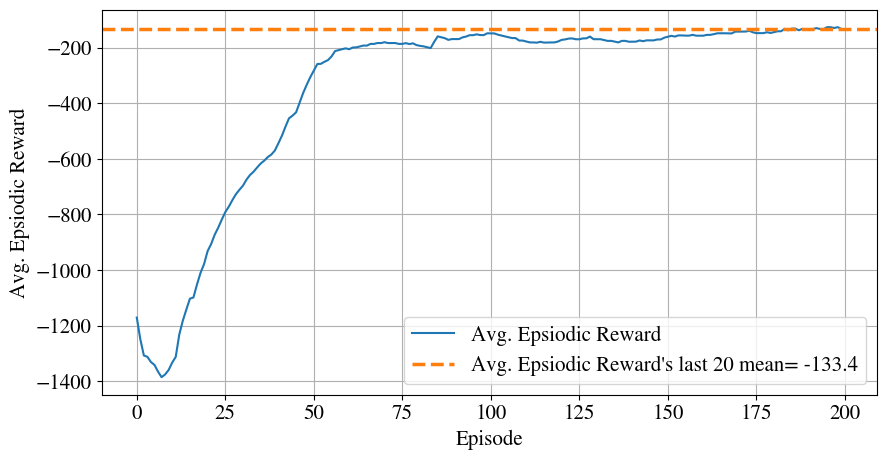

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's last 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Avg. Epsiodic Reward's last 20 mean=")
print(np.array(avg_reward_list)[-20:-1].mean())

Avg. Epsiodic Reward's last 20 mean=
-133.41551760494315


In [ ]:
#!pip install latex

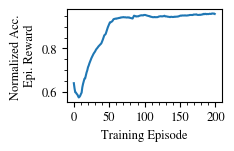

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Episodes versus Norm Acc. Ep. Rewards

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.0)
f.set_figheight(1.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. \nEpi. Reward")
#plt.grid()
#plt.legend()
plt.minorticks_on()
plt.xticks(np.arange(0, len(norm_reward_list)+1, 50))
#plt.yticks(np.arange(0.0, 1.0, 0.1))
plt.savefig(path_+"Pendulum_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Normalized Acc. Epsiodic Reward's last 20 mean=")
print(norm_reward_list[-20:-1].mean())

Normalized Acc. Epsiodic Reward's last 20 mean=
0.9590086036264432


In [ ]:
# Test Histogram
norm_ep_reward_list_test = np.array(ep_reward_list_test)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)

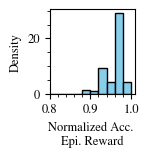

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(1.1)
f.set_figheight(1.1)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
#bins_norm = unnorm_to_norm(np.arange(-680,0,85))
plt.hist(data_rewards, bins=np.arange(0,1.01,0.02), density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. \nEpi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
plt.xticks(np.arange(0.8,1.01,0.1))
plt.minorticks_on()
plt.xlim((0.80,1.01))
plt.savefig(path_+"Pendulum_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=-5.650 ,mean=-148.123, std=75.052
Normalized:   max=9.983e-01 ,mean=9.545e-01, std=2.306e-02


In [ ]:
dt=env.dt

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3853/3534662450.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_, save_actual_torque , ':',label = "$y^{\mathrm{pm}}=a^{actual}$ from DC motor plant",color="red",linewidth = 4)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 

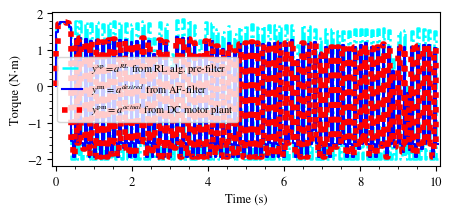

In [ ]:
time_ = np.linspace(start = 0, stop = len(save_actual_torque)* dt,num=len(save_actual_torque) )

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(5.0)
f.set_figheight(2.0)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
poly_fit = np.polynomial.polynomial.Polynomial.fit(x=time_[2:],y=e_ry[2:],deg=1,symbol='t')


plt.step(time_, save_sp_torque ,label = r"$y^{\mathrm{sp}}=a^{RL}$ from RL alg. pre-filter",color="cyan",linestyle='-.',linewidth = 1.8)
plt.step(time_, save_wanted_torque ,label = r"$y^{\mathrm{rm}}=a^{desired}$ from AF-filter",color="blue",linewidth = 1.5)
plt.step(time_, save_actual_torque , ':',label = "$y^{\mathrm{pm}}=a^{actual}$ from DC motor plant",color="red",linewidth = 4)
#plt.step(time_, e_ry,"--" ,label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$"+f": t≥"+str(2*dt)+"⇒"+"mean="+f'{e_ry[2:].mean():.4e}'+", std="+f'{e_ry[2:].std():.4e}'+",\n rms="+f'{np.sqrt((e_ry[2:]**2).mean()):.4e}'
#,color="black",linewidth = 2)
#plt.step(time_, e_ry ,label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 2)
#plt.axhline(y=e_ry.mean(), color="green",linewidth = 4, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.mean():.4e}')
#plt.axhline(y=np.sqrt((e_ry**2).mean()), color="black",linewidth = 4, linestyle='--', label='RMS($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{np.sqrt((e_ry**2).mean()):.4e}')
#plt.axhline(y=e_ry.std(), color="cyan",linewidth = 3, linestyle=(0, (3, 1, 1, 1)), label='STD($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.std():.4e}')

plt.minorticks_on()
plt.xlabel("Time (s)")
plt.ylabel("Torque (N⋅m)")
plt.legend(fontsize=7.5)#,bbox_to_anchor=(1, 1), loc='upper left')
#plt.grid()
plt.xlim(-0.1,10.1)
plt.savefig(path_+"Pendulum_Torque_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("for t≥"+str(2*dt)+",n≥2:")
print('error≈',poly_fit)
print("mean=", f'{e_ry[2:].mean():.4e}')
print("std=", f'{e_ry[2:].std():.4e}')
print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.1,n≥2:
error≈ -0.00070083 - 0.00022639·(-1.02020202 + 0.20101513t)
mean= -7.0083e-04
std= 6.2215e-03
rms= 6.2608e-03
mae= 5.7447e-03


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3853/3224808089.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_[2:], e_ry[2:], '--',label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 1.5)
/tmp/ipykernel_3853/3224808089.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(y=e_ry[2:].mean(), color="green",linewidth = 3, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry[2:].mean():.4e}')


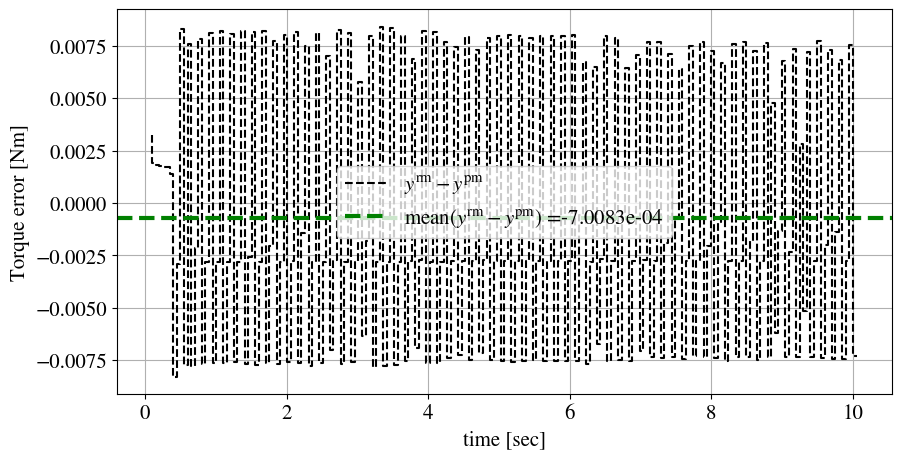

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)


plt.step(time_[2:], e_ry[2:], '--',label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 1.5)
plt.axhline(y=e_ry[2:].mean(), color="green",linewidth = 3, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry[2:].mean():.4e}')
#plt.axhline(y=np.sqrt((e_ry**2).mean()), color="black",linewidth = 4, linestyle='--', label='RMS($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{np.sqrt((e_ry**2).mean()):.4e}')
#plt.axhline(y=e_ry.std(), color="cyan",linewidth = 3, linestyle=(0, (3, 1, 1, 1)), label='STD($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.std():.4e}')

plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=15)
#plt.legend(fontsize=10,bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid()
plt.show()

In [ ]:
#from scipy.integrate import cumulative_trapezoid

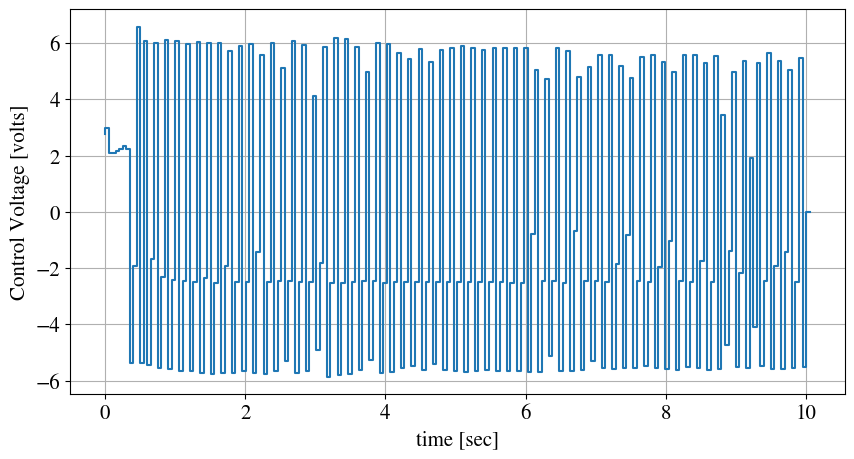

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

#time_u = np.linspace(start = 0, stop = len(save_ctrl_voltage)* dt,num=len(save_ctrl_voltage) )

plt.step(time_, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
plt.grid()
plt.show()

In [ ]:
import math

x_print = []
y_print = []
thetadot_print = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      x_print.append(value)
    if index == 1:
      y_print.append(value)
    if index == 2:
      thetadot_print.append(value)

theta_print = list(np.arctan2(np.array(y_print), np.array(x_print)))

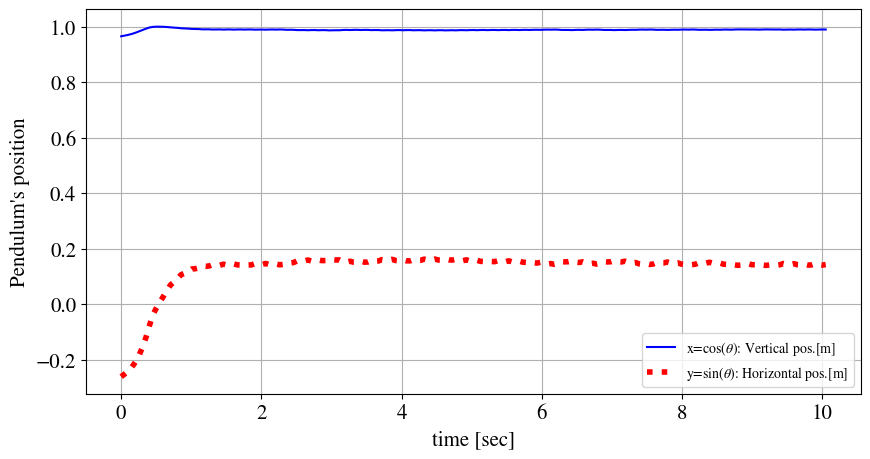

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

plt.plot(time_, x_print,
         label = r"x=cos($\theta$): Vertical pos.[m]",color="blue",linewidth = 1.5)
plt.plot(time_, y_print,':',
         label = r"y=sin($\theta$): Horizontal pos.[m]",color="red",linewidth = 4)
plt.xlabel("time [sec]")
plt.ylabel("Pendulum's position")
plt.grid()
plt.legend(fontsize=10)
plt.show()

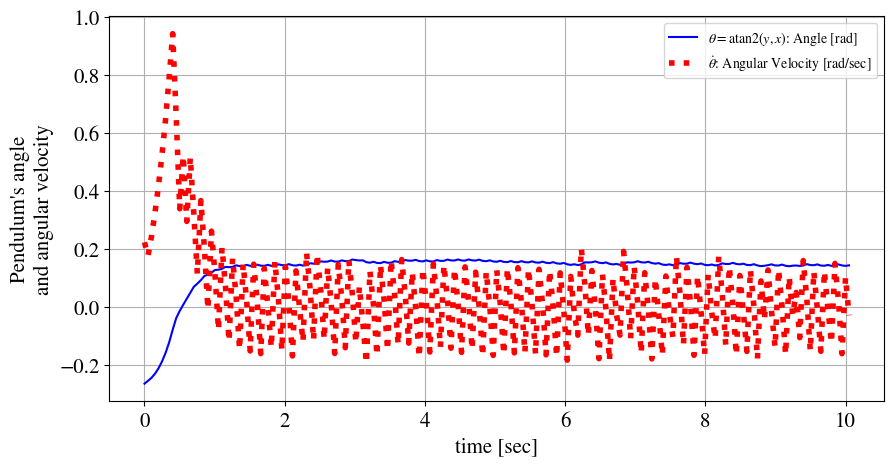

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')


plt.plot(time_, theta_print,
         label = r"$\theta=\mathrm{atan2}(y,x)$: Angle [rad]",color="blue",linewidth = 1.5)
plt.plot(time_, thetadot_print,':',
         label = r"$\dot{\theta}$: Angular Velocity [rad/sec]",color="red",
         linewidth = 4)
plt.xlabel("time [sec]")
plt.ylabel("Pendulum's angle\nand angular velocity")
plt.grid()
plt.legend(fontsize=10)
plt.show()

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_theta_print = np.linspace(start = 0, stop = len(theta_print)* dt,num=len(theta_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_theta_print[-1] , 300)
spl = make_interp_spline(time_theta_print, theta_print, k=3)  # type: BSpline
power_smooth_theta = spl(xnew)

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)
spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth_theta_dot = spl(xnew)

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


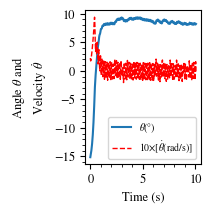

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(1.5)
f.set_figheight(2)

plt.plot(xnew, 180*power_smooth_theta/np.pi,label=r'$\theta(\degree)$',linewidth = 1.5)
plt.plot(xnew, 10*power_smooth_theta_dot,'--',color='red',label=r'10$\times$[$\dot{\theta}$(rad/s)]',linewidth = 1)
plt.minorticks_on()
plt.xlabel("Time (s)")
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
#plt.ylabel(r'Angle $\theta$ (rad) and'+'\n'+r'Angular velocity $\dot{\theta}$ (rad/s)')
plt.ylabel(r'Angle $\theta$ and'+'\n' +r'Velocity $\dot{\theta}$')
#plt.grid()
plt.legend(fontsize=7)
plt.savefig(path_+"Pendulum_Angle_and_Velocity_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
force_square_mean = (np.array(save_actual_torque)**2).mean()
power_smooth_theta_mean = np.array(power_smooth_theta).mean()
power_smooth_square_theta_mean = np.array(power_smooth_theta**2).mean()
power_smooth_theta_dot_mean = np.array(power_smooth_theta_dot).mean()
power_smooth_square_theta_dot_mean = np.array(power_smooth_theta_dot**2).mean()

In [ ]:
reward_mean = -(power_smooth_square_theta_mean+0.1*power_smooth_square_theta_dot_mean+0.001*force_square_mean)

In [ ]:
print(f'F^2 mean={force_square_mean:.2f}')
print(f'theta mean={power_smooth_theta_mean:.2e} ({180*power_smooth_theta_mean/np.pi:.2f} degrees)')
print(f'theta_dot mean={power_smooth_theta_dot_mean:.2e}')
print(f'theta^2 mean={power_smooth_square_theta_mean:.2e}')
print(f'theta_dot^2 mean={power_smooth_square_theta_dot_mean:.2e}')

F^2 mean=2.38
theta mean=1.30e-01 (7.44 degrees)
theta_dot mean=4.10e-02
theta^2 mean=2.25e-02
theta_dot^2 mean=3.16e-02


In [ ]:
print(f'reward_mean (in time) = {reward_mean:.2e}')
print(f'acc. episodic of mean reward={200*reward_mean:.3f}')

reward_mean (in time) = -2.80e-02
acc. episodic of mean reward=-5.602
